<a href="https://colab.research.google.com/github/Geovana2302/IA-Generativas-Aplicada-a-Programacao-ChatGPT/blob/main/K_MEANS_IRIS_Aula_21_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.optimize import linear_sum_assignment

In [ ]:
from sklearn.datasets import load_iris

# Carrega o dataset Iris
iris = load_iris()

# Cria o DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Adiciona a coluna 'Species' (rótulos)
df['species'] = iris.target_names[iris.target]

# Renomeia a coluna 'species' para 'Species' para consistência com o notebook original
df = df.rename(columns={'species': 'Species'})

print("DataFrame 'df' carregado com sucesso a partir de sklearn.datasets.load_iris()")

DataFrame 'df' carregado com sucesso a partir de sklearn.datasets.load_iris()


In [ ]:
# VISUALIZAR O DATAFRAME - MOSTRAR AS PRIMEIRAS LINHAS
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
# TRANSFORM RÓTULOS DE TEXTO PARA NÚMEROS
from sklearn.preprocessing import LabelEncoder

label_encodar = LabelEncoder()
y_true = label_encodar.fit_transform(df['Species'])

In [ ]:
# VISUALIZAR A TRANSFORMAÇÃO DE TEXTO PARA NÚEMEROS DA COLUNA Species
y_true

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

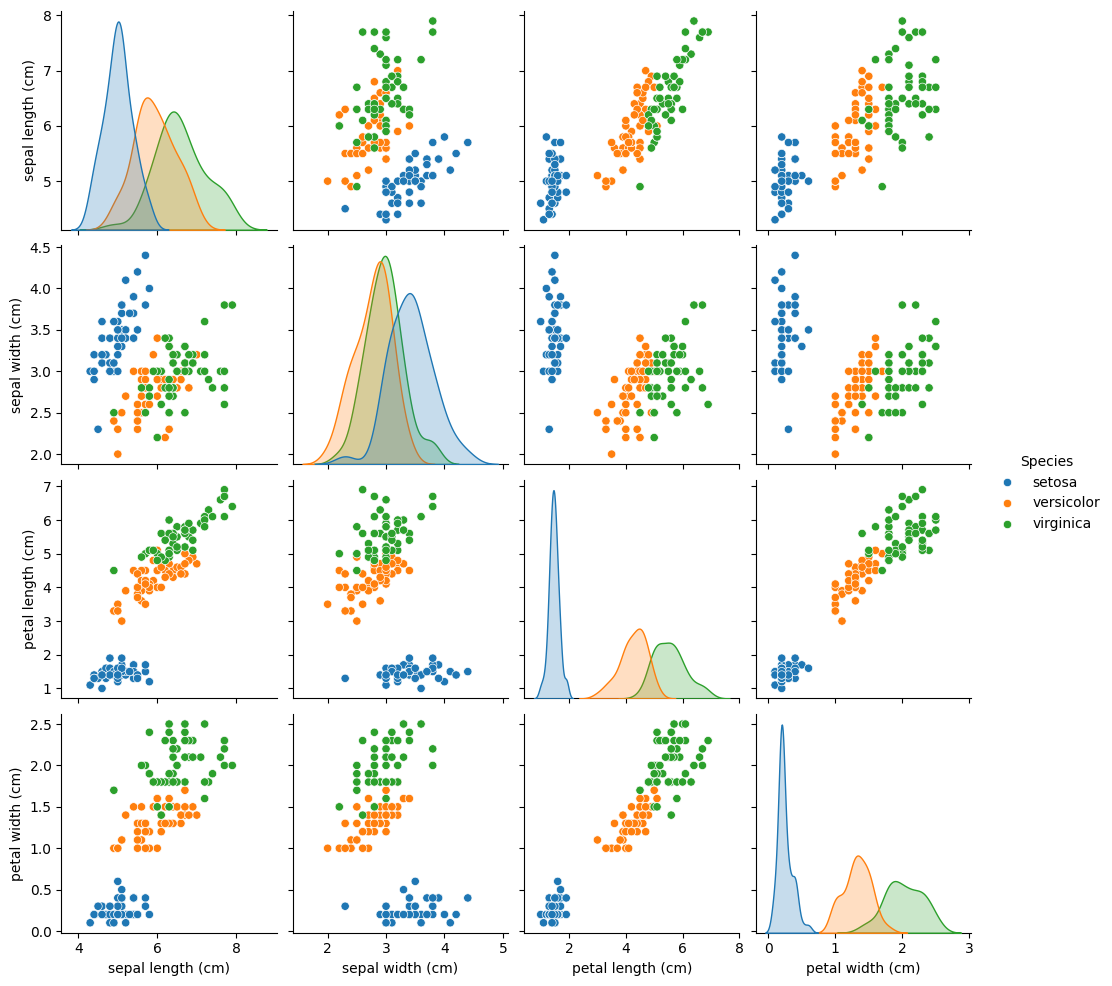

In [ ]:
# VISUALIZAR O DATAFRAME ORIGINAL
sb.pairplot(df, hue="Species")

In [ ]:
# COPIA DO DATAFRAME ORIGINAL REMOVENDO A COLUNA (RÓTULO LABEL) Species e ID
X = np.array(df.drop( 'Species', axis=1))
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
# DEFININDO O K
# CRIANDO O OBJETO KMEANS PASSANDO O NUMERO DE CLUSTERS
# TREINAMENTO INICIAL DOS DADOS SEM O RÓTULO
k = 3
kmeans = KMeans(n_clusters=k)
clusters = kmeans.fit_predict(X)
print(clusters)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [ ]:
# RECONSTRUI O OBJETO COM NÚMERO DE CLUSTER E FORÇANDO SEMPRE A COMEÇAR DO MESMO PONTO
kmeans = KMeans(n_clusters=k, random_state=0)

In [ ]:
# TREINAMENTO DO DATAFRAME SEM O ROTULO SPECIES UTILIZANDO KMEANS
kmeans.fit(X)

KMeans(n_clusters=3, random_state=0)

In [ ]:
# EXIBIR OS ROTULOS QUE FORMA GERADOS
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [ ]:
# CRIANDO UMA NOVA COLUNA DO DATAFRAME ORIGINAL INSERINDO OS LABELS DO DATAFRANE QUE FOI TREINADO
df['k_classes'] = kmeans.labels_

In [ ]:
# EXIBE AS 100 PRIMEIRAS LINHAS DO DATAFRAME ORIGINAL COM A NOVA COLUNA
df.head(100)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species,k_classes
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,versicolor,0
96,5.7,2.9,4.2,1.3,versicolor,0
97,6.2,2.9,4.3,1.3,versicolor,0
98,5.1,2.5,3.0,1.1,versicolor,0


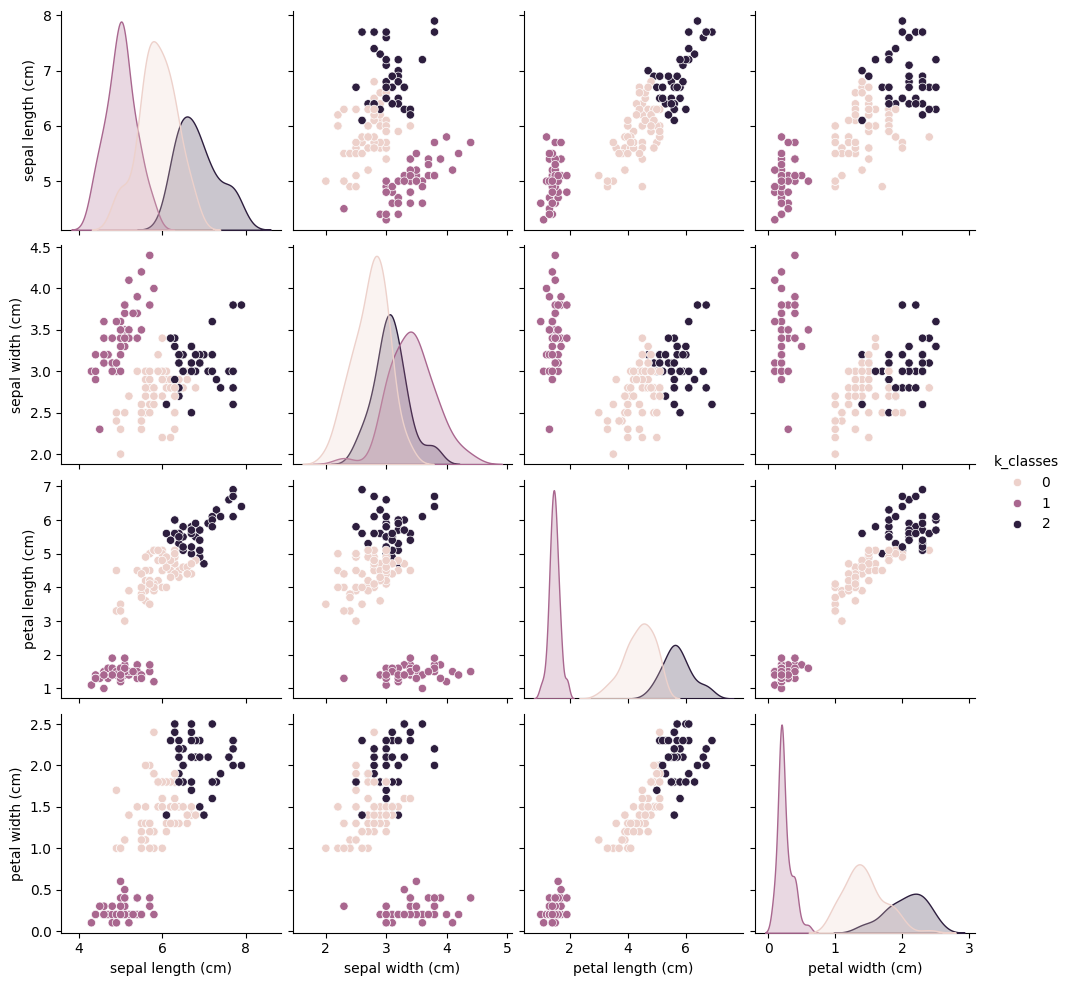

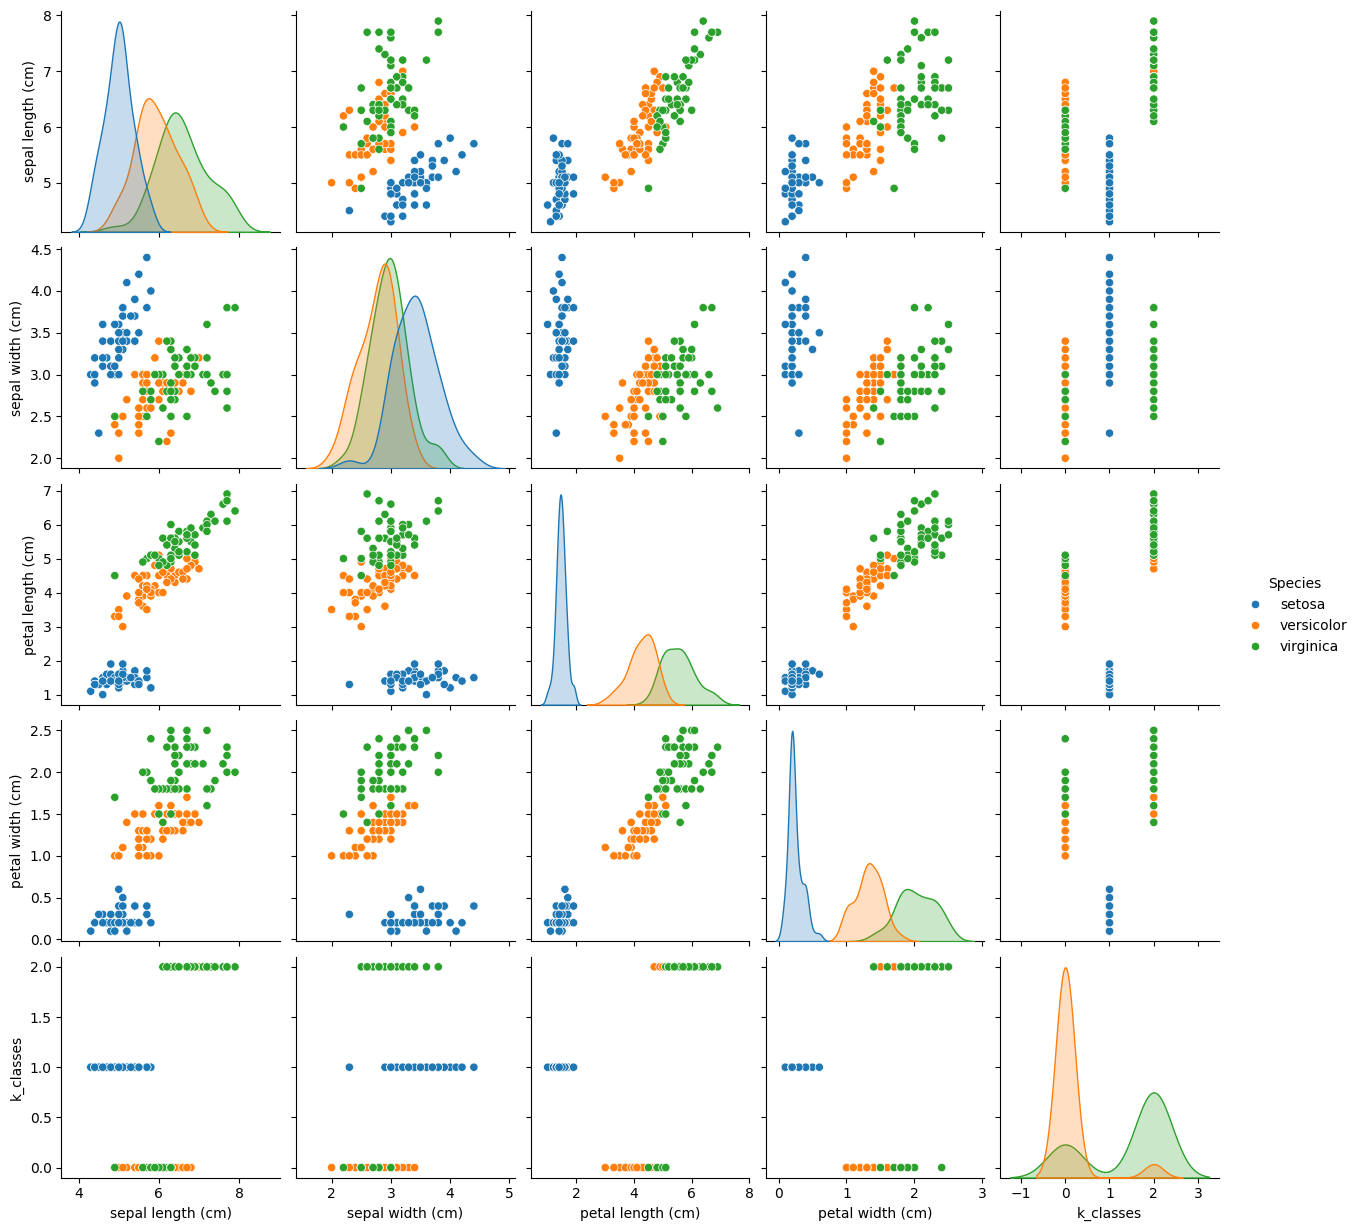

In [ ]:
sb.pairplot(df, hue='k_classes')
sb.pairplot(df, hue='Species')

In [ ]:
# IMPORTÇÃO DA MATRIX DE CONSUSÃO
# PASSA COMO ARGUMENTO y_true QUE É A TRANSFORMAÇÃO DA COLUNA SPECIES DO DF ORIGINAL
# PASSA COMO ARGUMENTO clusters LISTA DE AGRUPAMENTOS DO TREINO REALIZADO COM KMEANS
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_true, clusters)
row_ind, col_ind = linear_sum_assignment(-conf_matrix)


In [ ]:
clusters_mapeados = np.zeros_like(clusters)
for i, j in zip(row_ind, col_ind):
    clusters_mapeados[clusters == i] = j

In [ ]:
# REALIZAR A AUCURACIA PARA VERIFICAR A QUANTIDADE DE ACERTOS EM PERCENTUAL
acuracia = accuracy_score(y_true, clusters_mapeados)
print(f"Acurácia: {acuracia * 100:.2f}%")

Acurácia: 88.67%


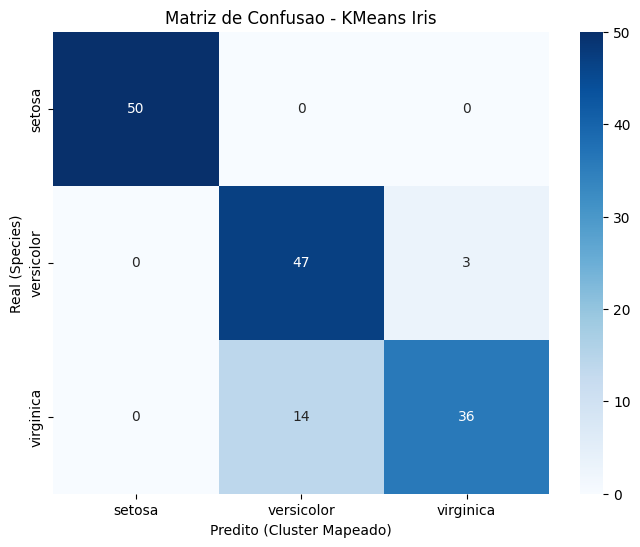

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Gerar a matriz de confusao usando os clusters mapeados
cm = confusion_matrix(y_true, clusters_mapeados)

# Plotar usando Seaborn para melhor visualizacao
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encodar.classes_,
            yticklabels=label_encodar.classes_)
plt.xlabel('Predito (Cluster Mapeado)')
plt.ylabel('Real (Species)')
plt.title('Matriz de Confusao - KMeans Iris')
plt.show()

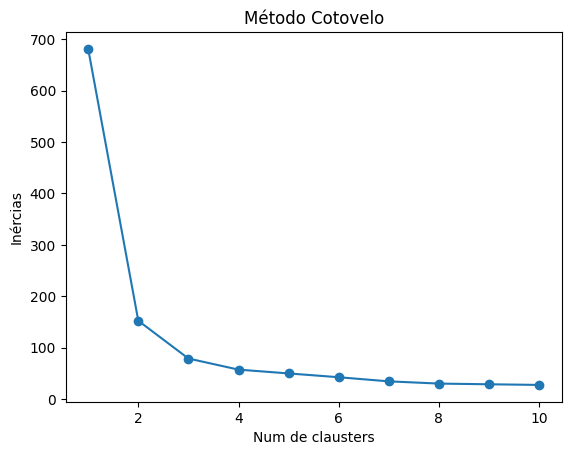

[681.3705999999996, 152.34795176035797, 78.85566582597727, 57.22847321428572, 49.8277405582923, 42.4215457530975, 34.42019178628389, 30.064593073593088, 28.71585653639446, 27.462118791296415]


In [ ]:
# ENCONTRAR O MELHOR K, O MELHORA AGRUPAMENTO
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inercias = []

for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=0)
  kmeans.fit(X)
  inercias.append(kmeans.inertia_)

plt.plot(range(1, 11), inercias, marker='o')
plt.xlabel('Num de clausters')
plt.ylabel('Inércias')
plt.title('Método Cotovelo')
plt.show()
print (inercias)

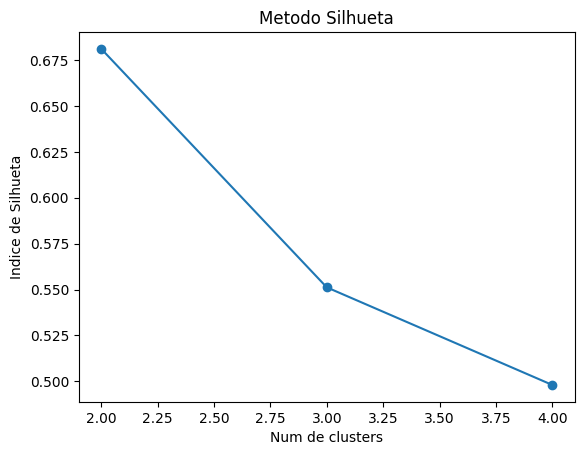

[np.float64(0.6810461692117465), np.float64(0.5511916046195927), np.float64(0.49805050499728815)]


In [74]:
# ESTE GRÁFICO MOSTRA O QUÃO PRÓXIMO UM PONTO ESTÁ DO SEU PRÓPRIO CLUSTER
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []

for k in range(2, 5):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 5), silhouette_scores, marker='o')
plt.xlabel('Num de clusters')
plt.ylabel('Indice de Silhueta')
plt.title('Metodo Silhueta')
plt.show()

print(silhouette_scores)

In [ ]:
%cd IA-Generativas-Aplicada-a-Programacao-ChatGPT


/content/IA-Generativas-Aplicada-a-Programacao-ChatGPT/IA-Generativas-Aplicada-a-Programacao-ChatGPT/IA-Generativas-Aplicada-a-Programacao-ChatGPT/IA-Generativas-Aplicada-a-Programacao-ChatGPT


In [ ]:
!git config --global user.email "geovanambicalho@hotmail.com"
!git config --global user.name "Geovana Bicalho"

In [ ]:
!git add .


In [ ]:
!git push

fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!git commit -m "Matriz de confusao"


On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
